In [68]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [69]:
data = pd.read_csv("../data/query.csv")

X = data["query"]
y = data["intent"]

In [70]:
data.sample(5)

,query,intent
189,International cultural program?,International_Affair
485,digital library page loading very slow please ...,Library
661,issue receiving placement notifications,Placements
199,Live industry project info?,Placements
2,Internet speed is very slow on campus,IT


In [71]:
data.shape

(859, 2)

In [72]:
print(data['intent'].value_counts())

intent
Examination                             87
Academics                               87
EDU_REV                                 85
Residential_Services                    77
Placements                              74
Library                                 70
Division_of_Research_and_Development    67
Fees_and_Account                        64
IT                                      60
Admissions                              50
Security_and_Safety                     44
International_Affair                    44
HOD_ML                                  27
HOD_MATH                                23
Name: count, dtype: int64


In [73]:
data = data.drop_duplicates(subset="query")
print("Dataset size after removing duplicates:", data.shape)
data = data.reset_index(drop=True)

Dataset size after removing duplicates: (858, 2)


In [74]:
import re
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

data['query'] = data['query'].apply(preprocess_text)
data.head()

,query,intent
0,how can i reset my university email password,IT
1,campus wifi is not working properly,IT
2,internet speed is very slow on campus,IT
3,i forgot my ums password,IT
4,ums portal login error is showing,IT


### Intent Distribution Graph

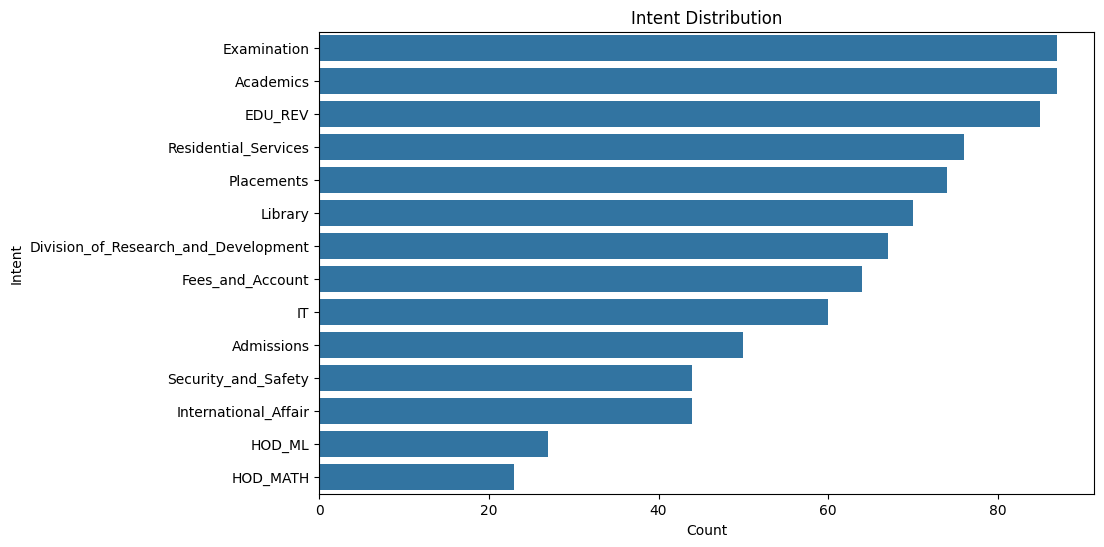

In [75]:
plt.figure(figsize=(10,6))

sns.countplot(y=data["intent"], order=data["intent"].value_counts().index)

plt.title("Intent Distribution")
plt.xlabel("Count")
plt.ylabel("Intent")

plt.show()

### Dataset Length Distribution

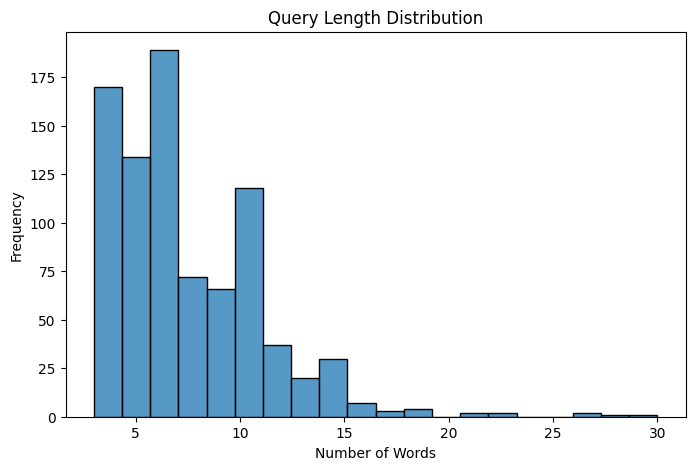

In [76]:
data["query_length"] = data["query"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(data["query_length"], bins=20)

plt.title("Query Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

### Pie Chart of Intents

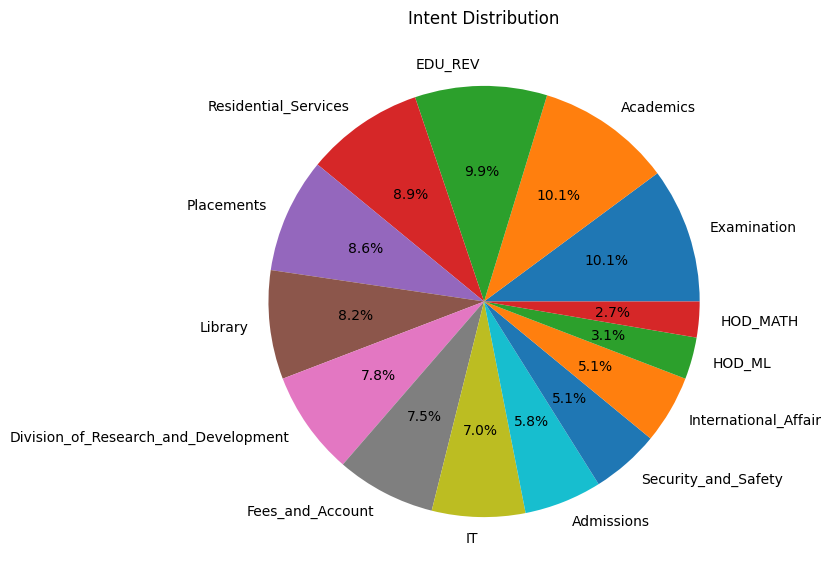

In [77]:
intent_counts = data["intent"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(intent_counts, labels=intent_counts.index, autopct='%1.1f%%')
plt.title("Intent Distribution")
plt.show()

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [79]:
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
X_train_embeddings = sbert_model.encode(
    X_train.tolist(),
    show_progress_bar=True
)

X_test_embeddings = sbert_model.encode(
    X_test.tolist(),
    show_progress_bar=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

In [80]:
clf = LogisticRegression(max_iter=1000)

clf.fit(X_train_embeddings, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [81]:
y_pred = clf.predict(X_test_embeddings)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Model Accuracy: 0.9186046511627907

Classification Report:

                                      precision    recall  f1-score   support

                           Academics       0.89      0.81      0.85        21
                          Admissions       0.90      0.75      0.82        12
Division_of_Research_and_Development       0.86      0.92      0.89        13
                             EDU_REV       1.00      0.90      0.95        20
                         Examination       0.78      1.00      0.88        14
                    Fees_and_Account       0.94      0.89      0.91        18
                            HOD_MATH       1.00      1.00      1.00         4
                              HOD_ML       1.00      1.00      1.00         1
                                  IT       0.89      0.89      0.89         9
                International_Affair       1.00      1.00      1.00         4
                             Library       1.00      1.00      1.00        16
   

In [82]:
joblib.dump(clf, "../models/intent_classifier.pkl")

['../models/intent_classifier.pkl']

In [83]:
query = ["I have applied for rpl for cse274 course"]

embedding = sbert_model.encode(query)

prediction = clf.predict(embedding)

probabilities = clf.predict_proba(embedding)

print("Predicted intent:", prediction)

print("Probabilities:", probabilities)

Predicted intent: ['EDU_REV']
Probabilities: [[0.16361523 0.06360565 0.04442528 0.20404494 0.09779986 0.01890322
  0.0198785  0.18481489 0.01993856 0.07332241 0.01149209 0.07346969
  0.01176124 0.01292846]]


### Confusion Matrix

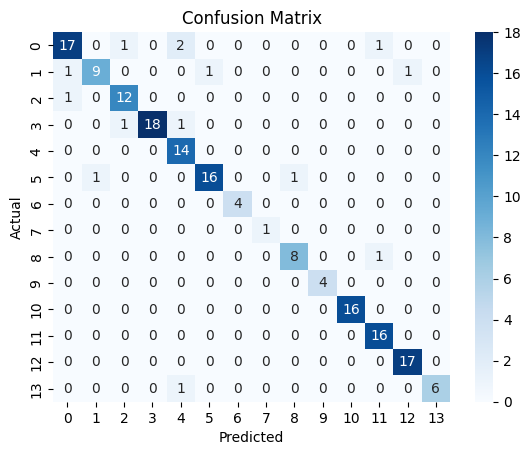

In [84]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Model Accuracy Graph

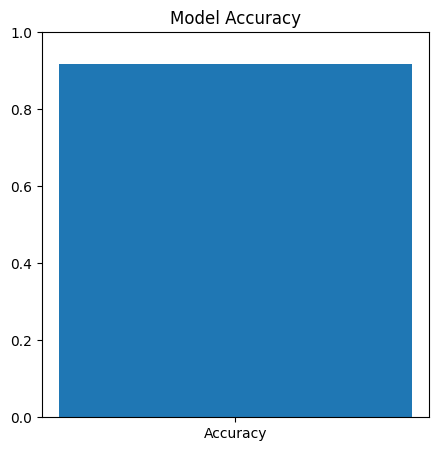

In [85]:

labels = ["Accuracy"]
values = [accuracy]
plt.figure(figsize=(5,5))
plt.bar(labels, values)
plt.title("Model Accuracy")
plt.ylim(0,1)
plt.show()